# Predicción de Consumo de Combustible (MPG) usando Random Forest

## Introducción

El objetivo de este proyecto es construir un modelo de aprendizaje supervisado capaz de predecir el consumo de combustible de automóviles, medido en millas por galón (MPG), a partir de características técnicas del vehículo.

El problema pertenece a la categoría de regresión supervisada debido a que la variable objetivo (MPG) es una variable numérica continua.

Para resolver este problema se utilizará el algoritmo Random Forest Regressor, un método de ensamble basado en árboles de decisión que combina múltiples modelos para mejorar la capacidad predictiva y reducir el sobreajuste.

Además de evaluar la precisión del modelo mediante métricas de regresión, se analizará la importancia de las variables para identificar cuáles características mecánicas tienen mayor influencia sobre el consumo de combustible.

## ¿Por qué Random Forest?

Un árbol de decisión individual puede ser muy sensible a pequeñas variaciones en los datos de entrenamiento, produciendo modelos con alta varianza.

Random Forest soluciona este problema mediante dos mecanismos:

1. Bagging (Bootstrap Aggregating)
2. Selección aleatoria de variables

El algoritmo construye múltiples árboles utilizando subconjuntos aleatorios de los datos y posteriormente combina sus predicciones mediante un promedio.

Esto permite:

- Reducir la varianza.
- Mejorar la generalización.
- Capturar relaciones no lineales.
- Identificar variables importantes.

In [1]:
import os, sys, random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Configuracion del entorno

In [2]:
import os, random
import numpy as np

# Rutas
BASE         = r'C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos'
DATA         = os.path.join(BASE, 'data')
PROJECT      = BASE
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

os.makedirs(os.path.join(BASE, 'figures'), exist_ok=True)

print('Rutas montadas y entorno listo')
print(f'   BASE: {BASE}')


Rutas montadas y entorno listo
   BASE: C:\Users\vigil\OneDrive\Desktop\DiplomadoCienciasDatos\modulo 5\Proyecto_Predicción_MPG_Autos


## Carga del conjunto de datos

El dataset utilizado es Auto MPG, que contiene información de 398 automóviles.

Cada observación representa un vehículo y sus características mecánicas.

La variable objetivo es:

MPG (Miles Per Gallon) que representa la eficiencia de combustible del automóvil.

Cargamos los splits ya preparados por el notebook de EDA: train_raw y test_raw: sin escalar.

In [3]:
# Random Forest no requiere escalado, usamos datos en escala original
train = pd.read_csv(f'{PROJECT}/data/train_raw.csv')
test  = pd.read_csv(f'{PROJECT}/data/test_raw.csv')

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']

X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Columnas: {list(X_train.columns)}")
print(f"\nMPG — mín: {y_train.min():.1f} | máx: {y_train.max():.1f} | media: {y_train.mean():.1f}")

Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']

MPG — mín: 9.0 | máx: 46.6 | media: 23.6


## Árbol de Decisión Simple (baseline previo a Random Forest)

Antes de entrenar Random Forest, entrenamos un árbol de decisión individual.

Esto nos permite ver el problema clave que RF resuelve: **un solo árbol
tiende a sobreajustarse** — memoriza el conjunto de entrenamiento pero
generaliza mal en datos nuevos.

Random Forest resuelve esto construyendo muchos árboles sobre muestras
distintas y promediando sus predicciones, reduciendo la varianza del modelo.

In [4]:
# ── Árbol de Decisión individual ─────────────────────────────────
# Entrenamos un árbol con profundidad máxima limitada (max_depth=5)
# para compararlo contra Random Forest.
# Sin límite de profundidad, el árbol memoriza el train (sobreajuste).

from sklearn.tree import DecisionTreeRegressor

arbol = DecisionTreeRegressor(
    max_depth    = 5,           # limita la profundidad para generalizar
    random_state = RANDOM_STATE
)
arbol.fit(X_train, y_train)

pred_arbol = arbol.predict(X_test)

mae_arbol  = mean_absolute_error(y_test, pred_arbol)
mse_arbol  = mean_squared_error(y_test, pred_arbol)
rmse_arbol = np.sqrt(mse_arbol)
r2_arbol   = r2_score(y_test, pred_arbol)

print('=== Árbol de Decisión (max_depth=5) ===')
print(f'  MAE  : {mae_arbol:.4f}')
print(f'  RMSE : {rmse_arbol:.4f}')
print(f'  R²   : {r2_arbol:.4f}')
print()
print('→ Compararemos estos resultados con Random Forest más adelante.')

=== Árbol de Decisión (max_depth=5) ===
  MAE  : 2.2842
  RMSE : 3.3034
  R²   : 0.7970

→ Compararemos estos resultados con Random Forest más adelante.


### ¿Por qué un árbol solo no es suficiente?

Un árbol de decisión individual tiene alta **varianza**: pequeños cambios
en los datos de entrenamiento producen árboles muy distintos.

Random Forest construye N árboles sobre muestras bootstrap distintas
y promedia sus predicciones. Al promediar, los errores individuales
se cancelan entre sí — esto reduce la varianza sin aumentar el sesgo.

## Entrenamiento del modelo

Se utilizarán 100 árboles de decisión.

Cada árbol será entrenado sobre una muestra bootstrap distinta.

La predicción final corresponderá al promedio de las predicciones individuales.

In [5]:
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [6]:
pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 1.591275
MSE = 4.6735265
RMSE = 2.1618340593116763
R² = 0.9130772620608741


## Resultados obtenidos

MAE = 1.5912
MSE = 4.6735
RMSE = 2.1618
R² = 0.9130

El Error Absoluto Medio (MAE) indica que, en promedio, el modelo se equivoca aproximadamente 1.6 MPG respecto al valor real.

Este error es relativamente pequeño considerando el rango de valores presentes en el conjunto de datos.

El RMSE es de aproximadamente 2.17 MPG.

Esta métrica penaliza más fuertemente los errores grandes, por lo que proporciona una medida conservadora del desempeño del modelo.

El coeficiente de determinación obtenido fue R² = 0.913.

Esto significa que el modelo explica aproximadamente el 91.3% de la variabilidad observada en el consumo de combustible.

El resultado indica una capacidad predictiva elevada.

In [7]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

importancias

,Variable,Importancia
0,displacement,0.445074
3,weight,0.147996
1,cylinders,0.130165
2,horsepower,0.127329
5,model_year,0.115622
4,acceleration,0.027603
7,origin_3,0.003273
6,origin_2,0.002938


## Importancia de variables

Random Forest permite estimar qué variables fueron más útiles para realizar las predicciones.

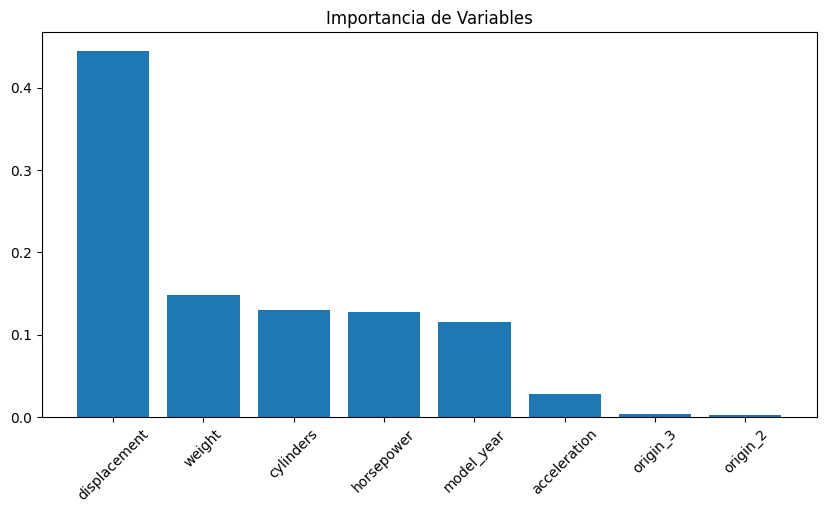

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.xticks(rotation=45)

plt.title("Importancia de Variables")
plt.savefig(f'{PROJECT}/figures/Importancias_baseline_rf.png',
            bbox_inches='tight')
plt.show()

Los resultados muestran que la variable más importante fue:

displacement (44.5%)

seguida por:

- weight (14.8%)
- cylinders (13.0%)
- horsepower (12.7%)
- model_year (11.6%)

Esto sugiere que el tamaño del motor es el principal factor para explicar el consumo de combustible en este conjunto de datos.

Desde una perspectiva física, motores con mayor cilindrada suelen requerir más combustible para operar, lo que reduce la eficiencia energética del vehículo.

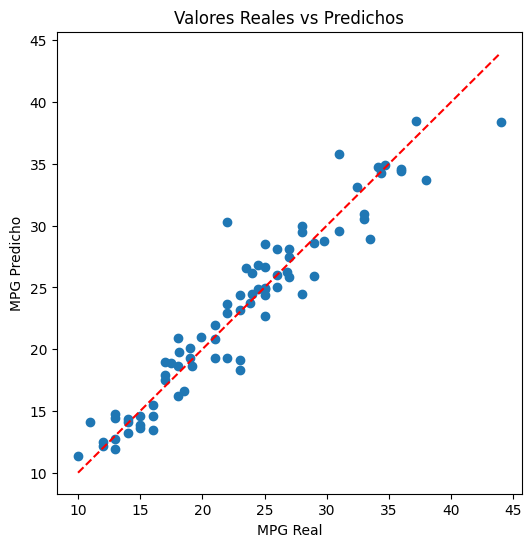

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("MPG Real")
plt.ylabel("MPG Predicho")

plt.title("Valores Reales vs Predichos")
plt.savefig(f'{PROJECT}/figures/reales_vs_predichos_rf.png',
            bbox_inches='tight')
plt.show()

# GridSearch

Realizaremos un GridSearch para la busqueda de los mejores hiperparametros.

In [10]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid = param_grid_rf,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_rf.best_params_}")
print(f"Mejor R² en CV:     {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² en CV:     0.8555


Entrenaremos el mejor modelo

In [11]:
best_rf = grid_rf.best_estimator_

pred_best = best_rf.predict(X_test)

mae_best  = mean_absolute_error(y_test, pred_best)
mse_best  = mean_squared_error(y_test, pred_best)
rmse_best = np.sqrt(mse_best)
r2_best   = r2_score(y_test, pred_best)

print("Random Forest Optimizado")
print(f"MAE:  {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²:   {r2_best:.4f}")

Random Forest Optimizado
MAE:  1.5525
RMSE: 2.1287
R²:   0.9157


Importancias del mejor modelo.

In [12]:
importancias_best = pd.DataFrame({
    'Variable'   : X_train.columns,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

importancias_best

,Variable,Importancia
0,displacement,0.280453
3,weight,0.229877
1,cylinders,0.157122
2,horsepower,0.147874
5,model_year,0.132945
4,acceleration,0.041456
6,origin_2,0.005256
7,origin_3,0.005017


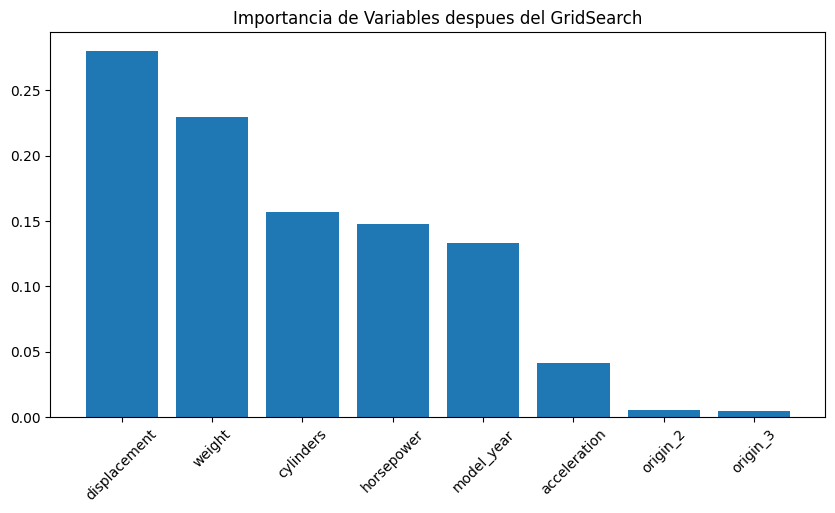

In [13]:
plt.figure(figsize=(10,5))

plt.bar(
    importancias_best["Variable"],
    importancias_best["Importancia"]
)

plt.xticks(rotation=45)

plt.title("Importancia de Variables despues del GridSearch")
plt.savefig(f'{PROJECT}/figures/Importancias_Best_rf.png',
            bbox_inches='tight')
plt.show()

Las importancias no cambiaron en lugar de importancia, sin embargo, su porcentaje subio para la mayoria de variables.

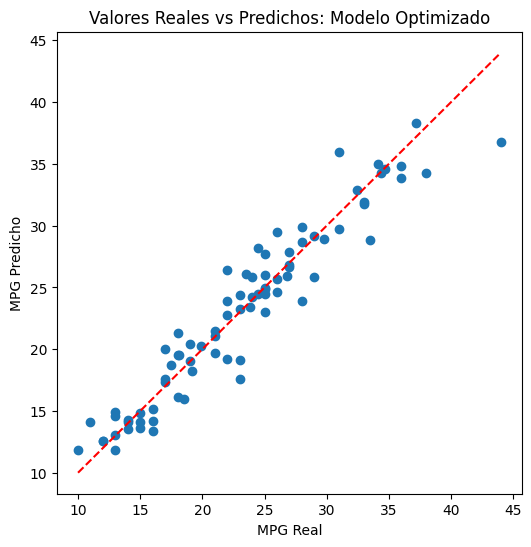

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("MPG Real")
plt.ylabel("MPG Predicho")

plt.title("Valores Reales vs Predichos: Modelo Optimizado")

plt.savefig(f'{PROJECT}/figures/reales_vs_predichos_rf_optimizado.png',
            bbox_inches='tight')
plt.show()

# Conclusiones

In [15]:
# ── Tabla comparativa final ──────────────────────────────────────
# Incluimos el árbol de decisión simple como punto de partida para
# mostrar la mejora que aporta Random Forest (bagging).

resultados_rf = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest Baseline', 'Random Forest Optimizado'],
    'MAE'   : [mae_arbol,  mae,      mae_best],
    'RMSE'  : [rmse_arbol, rmse,     rmse_best],
    'R²'    : [r2_arbol,   r2,       r2_best]
})

print('=== Comparativa final ===')
print(resultados_rf.round(4).to_string(index=False))

=== Comparativa final ===
                  Modelo    MAE   RMSE     R²
       Árbol de Decisión 2.2842 3.3034 0.7970
  Random Forest Baseline 1.5913 2.1618 0.9131
Random Forest Optimizado 1.5525 2.1287 0.9157



Se desarrolló exitosamente un modelo Random Forest Regressor para predecir
el consumo de combustible de automóviles utilizando el conjunto de datos Auto MPG.

El modelo baseline obtuvo:

- MAE = 1.591
- RMSE = 2.161
- R² = 0.913

Mientras que el modelo optimizado mediante GridSearch:

- MAE = 1.552
- RMSE = 2.128
- R² = 0.915

Ambos resultados indican una alta capacidad predictiva, explicando más del 91%
de la variabilidad observada en el consumo de combustible. La mejora del modelo
optimizado, aunque modesta, es consistente — confirma que los hiperparámetros
por defecto de scikit-learn son razonables para este dataset, y que el ajuste
fino aporta una ganancia real sin señales de sobreajuste.

El análisis de importancia de variables reveló que la cilindrada del motor
(displacement) constituye el factor más influyente sobre el consumo de
combustible, seguida por el peso del vehículo, el número de cilindros y la
potencia del motor.

Estos resultados son consistentes con principios físicos y de ingeniería
automotriz: vehículos más pesados y con motores más grandes requieren mayor
energía para operar, lo que se traduce directamente en un mayor consumo de
combustible.

Finalmente, Random Forest demostró ser una herramienta adecuada para este
problema por su capacidad de modelar relaciones no lineales, reducir el
sobreajuste mediante bagging y proporcionar interpretabilidad a través de
la importancia de variables.

In [16]:
resultados_rf.to_csv(f'{PROJECT}/data/metricas_rf.csv', index=False)

print("Archivos guardados:")
for a in sorted(os.listdir(f'{PROJECT}/data')):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos guardados:
  - auto_mpg_clean.csv
  - auto_mpg_clean.xlsx
  - metricas_boosting.csv
  - metricas_rf.csv
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv
